In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [4]:
df = pd.read_csv("../data/clinical_trials_cleaned.csv")

In [5]:
df.head()

,rank,nct_number,title,status,study_results,conditions,interventions,outcome_measures,sponsor_collaborators,gender,...,start_missing,primary_missing,completion_missing,country,start_year,start_month,primary_year,primary_month,completion_year,completion_month
0,1,NCT04785898,Diagnostic Performance of the ID Now™ COVID-19...,"Active, not recruiting",No Results Available,Covid19,Diagnostic Test: ID Now™ COVID-19 Screening Test,Evaluate the diagnostic performance of the ID ...,Groupe Hospitalier Paris Saint Joseph,All,...,0,0,0,France,2020.0,11.0,2020.0,12.0,2021.0,4.0
1,2,NCT04595136,Study to Evaluate the Efficacy of COVID19-0001...,Not yet recruiting,No Results Available,SARS-CoV-2 Infection,Drug: Drug COVID19-0001-USR|Drug: normal saline,Change on viral load results from baseline aft...,United Medical Specialties,All,...,0,0,0,Colombia,2020.0,11.0,2020.0,12.0,2021.0,1.0
2,3,NCT04395482,Lung CT Scan Analysis of SARS-CoV2 Induced Lun...,Recruiting,No Results Available,covid19,Other: Lung CT scan analysis in COVID-19 patients,A qualitative analysis of parenchymal lung dam...,University of Milano Bicocca,All,...,0,0,0,San Marino,2020.0,5.0,2021.0,6.0,2021.0,6.0
3,4,NCT04416061,The Role of a Private Hospital in Hong Kong Am...,"Active, not recruiting",No Results Available,COVID,Diagnostic Test: COVID 19 Diagnostic Test,Proportion of asymptomatic subjects|Proportion...,Hong Kong Sanatorium & Hospital,All,...,0,0,0,Hong Kong,2020.0,5.0,2020.0,7.0,2020.0,8.0
4,5,NCT04395924,Maternal-foetal Transmission of SARS-Cov-2,Recruiting,No Results Available,Maternal Fetal Infection Transmission|COVID-19...,Diagnostic Test: Diagnosis of SARS-Cov2 by RT-...,COVID-19 by positive PCR in cord blood and / o...,Centre Hospitalier Régional d'Orléans|Centre d...,Female,...,0,1,1,France,2020.0,5.0,0.0,0.0,0.0,0.0


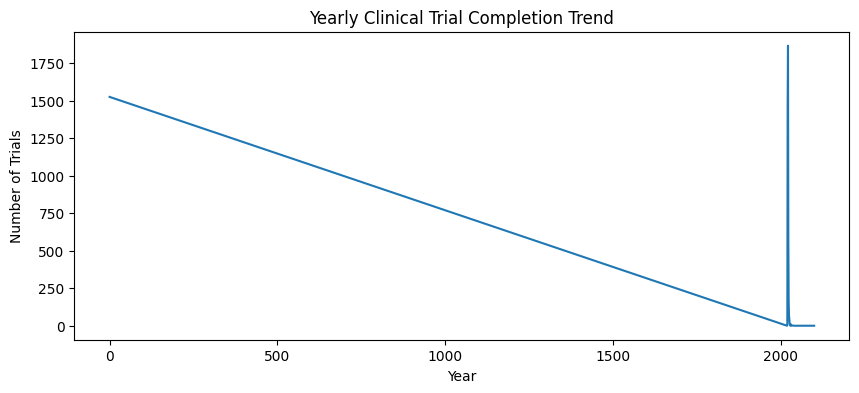

In [11]:
completion_trend = df.groupby('completion_year').size()

completion_trend.plot(figsize=(10,4))
plt.title("Yearly Clinical Trial Completion Trend")
plt.xlabel("Year")
plt.ylabel("Number of Trials")
plt.savefig('../images/completion_trend', dpi=300, bbox_inches='tight')
plt.show()

#### ARIMA Forecast Model

In [ ]:
model = ARIMA(completion_trend, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)

print("Next 5 Years Forecast:")
print(forecast)

c:\Users\hp\Desktop\Power BI\internship\all_projects\Covid_19_clinical_EDA_ML\env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\hp\Desktop\Power BI\internship\all_projects\Covid_19_clinical_EDA_ML\env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\hp\Desktop\Power BI\internship\all_projects\Covid_19_clinical_EDA_ML\env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._i

Next 5 Years Forecast:
21    7.899307
22    6.693445
23    6.904206
24    6.867369
25    6.873808
Name: predicted_mean, dtype: float64


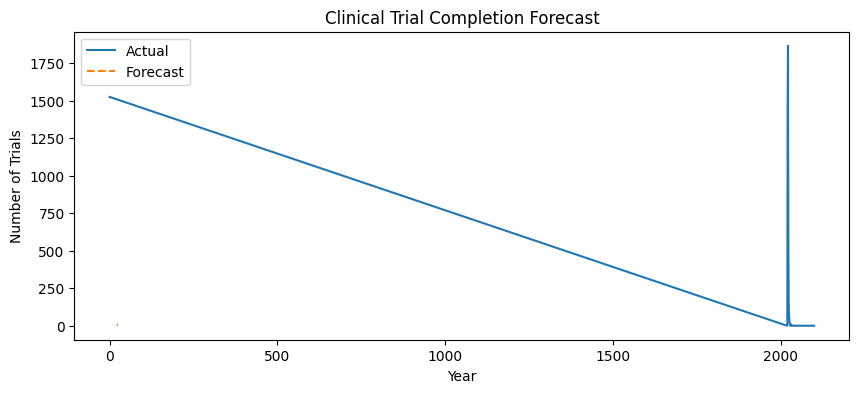

In [17]:
plt.figure(figsize=(10,4))
completion_trend.plot(label="Actual")
forecast.plot(label="Forecast", linestyle="dashed")

plt.title("Clinical Trial Completion Forecast")
plt.xlabel("Year")
plt.ylabel("Number of Trials")
plt.legend()
plt.savefig('../images/completion_forecast', dpi=300, bbox_inches='tight')
plt.show()